#  <center> Taller  de Aprendizaje Automático </center>
##  <center> Taller 4: Detección de Anomalías  </center>

# Introducción

En la siguiente actividad se trabajará en la detección de anomalías sobre redes de computadoras a partir de datos de tráfico. El objetivo será construir un modelo capaz de distinguir entre malas conexiones o ataques, y buenas conexiones, llamadas normales. Para esto se utilizará una parte del conjunto [KDD Cup'99](https://scikit-learn.org/stable/datasets/real_world.html#kddcup99-dataset) pensada para evaluar métodos de detección de anomalías. 

Para los problemas de detección de anomalías generalmente no se cuenta con datos etiquetados para entrenar un detector. Por su definición las anomalías son eventos raros y por lo tanto poco frecuentes, lo que dificulta el etiquetado. Es por esto que este tipo de tareas generalmente son no supervisadas.

El enfoque más habitual para implementar soluciones para este tipo de problemas, es crear un modelo base a partir de un conjunto de datos "normales", es decir de los cuales se tenga cierta certeza de que todos fueron adquiridos en una situación normal. Luego, en producción se detectarán como datos anómalos todos aquellos que no se ajusten a este modelo. Para saber el grado de ajuste de los datos se debe seleccionar un punto de operación, es decir, determinar cuándo un dato se considera anómalo. En un ejemplo real, el cliente primero debería proporcionar una cantidad considerable de datos que representen el comportamiento normal de su sistema. Luego que se tiene el mejor modelo posible de estos datos, junto con el cliente, que es el que conoce su sistema, se debe determinar el punto de operación a partir del compromiso entre detectar la mayor cantidad de anomalías y obtener la menor cantidad de falsas alarmas posibles.

Para hacer investigación en la detección de anomalías, existen conjuntos de datos como el que se trabajará en esta actividad que si tienen etiquetas. Generalmente estas se obtienen provocando fallas y/o ataques intencionales a un sistema que se encuentra funcionando de manera normal. En esta actividad se separará el conjunto de entrenamiento en dos partes. La primera con una gran proporción de datos etiquetados como normales, simulará ser el conjunto que el cliente nos proporciona para entrenar nuestro modelo. El otro conjunto tendrá datos etiquetados como normales y como anómalos, que se utilizará para definir el punto de operación. Asimismo, se tendrá un conjunto de test asociados a este problema para evaluar la puesta en producción del modelo. 

## Objetivos


*   Abordar un problema de detección de anomalías, y ver las diferencias con un problema de clasificación convencional.
*   Trabajar con algoritmos de aprendizaje no supervisado.
*   Crear detectores compatibles con los *pipelines* de *scikit-learn*.


# Datos

### Parte 1 - Levantar los Datos

#### Conjunto de Entrenamiento

El conjunto de datos [KDD Cup'99](https://scikit-learn.org/stable/datasets/real_world.html#kddcup99-dataset) contiene un conjunto de datos de tráfico de red que incluye tráfico normal y malicioso. El conjunto de datos para entrenamiento contiene 100655 instancias donde cada una cuenta con 41 características entre las que se encuentran la duración de la conexión, los tipos de protocolo, los tipos de servicios, entre otros. Por más información sobre el contenido de las características haga clic [aquí](http://kdd.ics.uci.edu/databases/kddcup99/task.html). Además, se cuenta con la columna *'labels'* que indica si el dato es normal o, de no serlo, indica el tipo de anomalía.

#### Ejercicios:

 - Ejecute la siguientes celdas para levantar el conjunto de datos de entrenamiento. 
 - Observar la cantidad de muestras por tipo. 
 - Determinar la relación entre datos normales y anómalos.  

In [70]:
#Importo bibliotecas:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.metrics import precision_recall_curve

In [71]:
import pandas as pd
import numpy as np
import time
from sklearn.datasets import fetch_kddcup99

#Se obtienen los datos en formato de diccionario
KDDSA = fetch_kddcup99(subset='SA', as_frame=True, random_state=42)

#A partir del diccionario se crea un Dataframe con los datos
df = pd.DataFrame(data=KDDSA.frame.values, columns=KDDSA.frame.columns)

#Se estandariza el formato de los datos en el Dataframe 
types = [float, str, str,str, float, float, str, float, float, float, float, str, float, float,float, float, float, float, float, float, str, str, 
         float, float, float, float,float, float, float, float,float, float, float, float, float, float, float,float, float, float, float, str]

columns = df.columns
for i in range(len(columns)):
    df[columns[i]] = df[columns[i]].astype(types[i])
    if types[i] == str:
        df[columns[i]]= df[columns[i]].str.replace("b'", "")
        df[columns[i]]= df[columns[i]].str.replace("'", "")

#Visualizo
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0.0,tcp,http,SF,181.0,5450.0,0,0.0,0.0,0.0,...,9.0,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.
1,0.0,tcp,http,SF,239.0,486.0,0,0.0,0.0,0.0,...,19.0,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.
2,0.0,tcp,http,SF,235.0,1337.0,0,0.0,0.0,0.0,...,29.0,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
3,0.0,tcp,http,SF,219.0,1337.0,0,0.0,0.0,0.0,...,39.0,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
4,0.0,tcp,http,SF,217.0,2032.0,0,0.0,0.0,0.0,...,49.0,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.


In [72]:
# Contar la cantidad de muestras por tipo
print("\nCantidad de muestras por tipo:")
counts = df['labels'].value_counts()
print(counts)


Cantidad de muestras por tipo:
labels
normal.             97278
smurf.               2409
neptune.              898
back.                  15
satan.                 15
ipsweep.               10
teardrop.               9
portsweep.              8
warezclient.            8
pod.                    3
buffer_overflow.        1
land.                   1
Name: count, dtype: int64


In [73]:
# Calcular la proporción de cada tipo de dato
total_samples = counts.sum()
normal_samples = counts['normal.']  
anomalous_samples = total_samples - normal_samples

# Calcular la proporción
normal_proportion = normal_samples / total_samples
anomalous_proportion = anomalous_samples / total_samples

# Imprimir resultados
print("\nProporción de muestras normales:", normal_proportion)
print("Proporción de muestras anómalas:", anomalous_proportion)



Proporción de muestras normales: 0.9664497541105758
Proporción de muestras anómalas: 0.03355024588942427


#### Conjunto de Test

Este problema tiene disponible un conjunto de datos para Test, estos se pueden encontar [aquí](https://kdd.ics.uci.edu/databases/kddcup99/kddcup99.html). 

#### Ejercicios:

 - Descargar y levantar los datos de Test. 
 - Separar los datos de las etiquetas.

In [74]:
#Levanto los datos de Test
test_data = pd.read_csv('./corrected.gz', header=None)

test_data.columns = columns

#Se estandariza el formato de los datos en el Dataframe 
types = [float, str, str,str, float, float, str, float, float, float, float, str, float, float,float, float, float, float, float, float, str, str, 
         float, float, float, float,float, float, float, float,float, float, float, float, float, float, float,float, float, float, float, str]

for i in range(len(columns)):
    test_data[columns[i]] = test_data[columns[i]].astype(types[i])

test_data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0.0,udp,private,SF,105.0,146.0,0,0.0,0.0,0.0,...,254.0,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal.
1,0.0,udp,private,SF,105.0,146.0,0,0.0,0.0,0.0,...,254.0,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal.
2,0.0,udp,private,SF,105.0,146.0,0,0.0,0.0,0.0,...,254.0,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal.
3,0.0,udp,private,SF,105.0,146.0,0,0.0,0.0,0.0,...,254.0,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,snmpgetattack.
4,0.0,udp,private,SF,105.0,146.0,0,0.0,0.0,0.0,...,254.0,1.0,0.01,0.01,0.0,0.0,0.0,0.0,0.0,snmpgetattack.


In [75]:
#Separo los datos de las etiquetas
y_train = df['labels']
X_train = df.drop(columns=['labels'])

### Parte 2 - Preparar Conjuntos

#### Ejercicios:

Manteniendo el orden de los datos de Entrenamiento:

 - Separar las primeras 90000 muestras para entrenamiento con sus respectivas etiquetas. Estos deberían estar etiquetados como *normales*.
 - Separar las restantes muestras y sus respectivas etiquetas para validación.  Este conjunto permitirá fijar el punto de operación del modelo.

In [76]:
#Separo los datos a huevo:

#Val
X_val = X_train[90000:]
y_val = y_train[90000:]

#Train
X_train = X_train[:90000]
y_train = y_train[:90000]

#Test
y_test = test_data['labels']
X_test = test_data.drop(columns=['labels'])

In [77]:
#Verifico las anomalias presentes en cada conjunto
print('Tipo de datos en Entrenamiento:\n',np.unique(y_train))
print('Tipo de datos en Validacion:\n',np.unique(y_val))
print('Tipo de datos en Test:\n',np.unique(y_test))

Tipo de datos en Entrenamiento:
 ['normal.']
Tipo de datos en Validacion:
 ['back.' 'buffer_overflow.' 'ipsweep.' 'land.' 'neptune.' 'normal.' 'pod.'
 'portsweep.' 'satan.' 'smurf.' 'teardrop.' 'warezclient.']
Tipo de datos en Test:
 ['apache2.' 'back.' 'buffer_overflow.' 'ftp_write.' 'guess_passwd.'
 'httptunnel.' 'imap.' 'ipsweep.' 'land.' 'loadmodule.' 'mailbomb.'
 'mscan.' 'multihop.' 'named.' 'neptune.' 'nmap.' 'normal.' 'perl.' 'phf.'
 'pod.' 'portsweep.' 'processtable.' 'ps.' 'rootkit.' 'saint.' 'satan.'
 'sendmail.' 'smurf.' 'snmpgetattack.' 'snmpguess.' 'sqlattack.'
 'teardrop.' 'udpstorm.' 'warezmaster.' 'worm.' 'xlock.' 'xsnoop.'
 'xterm.']


El código anterior muestra la cantidad de clases presente en cada conjunto. Verifique que en el conjunto de Entrenamiento solo hay muestras normales. 

Es importante tener en cuenta que los datos de Test presentan una distribución de probabilidad diferente a la de los datos de entrenamiento y validación, de hecho, contienen tipos específicos de ataques. Este aspecto es crucial para hacer la tarea de detección de anomalías más realista.

Los ataques informáticos pueden ser clasificados en diferentes categorías, las cuales se definen en función de su objetivo y método de ejecución. Es usual, categorizar los ataques en cuatro tipos principales: 

* **DoS**: Tienen como objetivo abrumar un sistema o red con una gran cantidad de tráfico, lo que puede resultar en una disminución o pérdida total del servicio , e.g. syn flood;
* **R2L**: Buscan obtener acceso no autorizado a un sistema desde una máquina remota, e.g. adivinar la contraseña;
* **U2R**: Buscan obtener acceso no autorizado a privilegios de superusuario local o raíz., e.g., various ''buffer overflow'' attacks;
* **probing**: Consisten en la vigilancia y exploración de, por ejemplo, puertos y/o servicios en busca de vulnerabilidades que puedan ser explotadas posteriormente.

A continuación, se otorga un diccionario de correspondencia entre las anomalías y la categoría correspondiente.

In [78]:
# Se define un diccionario con la correspondencia entre la anomalía y la categoría
attack_dict = {
    'normal.': 'normal',
    
    'back.': 'DoS',
    'land.': 'DoS',
    'neptune.': 'DoS',
    'pod.': 'DoS',
    'smurf.': 'DoS',
    'teardrop.': 'DoS',
    'mailbomb.': 'DoS',
    'apache2.': 'DoS',
    'processtable.': 'DoS',
    'udpstorm.': 'DoS',
    
    'ipsweep.': 'Probe',
    'nmap.': 'Probe',
    'portsweep.': 'Probe',
    'satan.': 'Probe',
    'mscan.': 'Probe',
    'saint.': 'Probe',

    'ftp_write.': 'R2L',
    'guess_passwd.': 'R2L',
    'imap.': 'R2L',
    'multihop.': 'R2L',
    'phf.': 'R2L',
    'spy.': 'R2L',
    'warezclient.': 'R2L',
    'warezmaster.': 'R2L',
    'sendmail.': 'R2L',
    'named.': 'R2L',
    'snmpgetattack.': 'R2L',
    'snmpguess.': 'R2L',
    'xlock.': 'R2L',
    'xsnoop.': 'R2L',
    'worm.': 'R2L',
    
    'buffer_overflow.': 'U2R',
    'loadmodule.': 'U2R',
    'perl.': 'U2R',
    'rootkit.': 'U2R',
    'httptunnel.': 'U2R',
    'ps.': 'U2R',    
    'sqlattack.': 'U2R',
    'xterm.': 'U2R'
}

Antes de finalizar se deberán cambiar las etiquetas de los datos en todos los conjuntos a 0 y 1. Siendo 0 la etiqueta de la clase normal y 1 la etiqueta de la clase anómala.

#### Objetivos:
 - Cambiar las etiquetas de los datos en todos los conjuntos a 0 y 1.
 
**Comentario**: Se sugiere en alguna variable distinta conservar los valores originales.

In [79]:
#Cambio las etiquetas a binario:

#Train
y_train_ = y_train.copy()
y_train = (y_train != 'normal.').astype(int)

#Val
y_val_ = y_val.copy()
y_val = (y_val != 'normal.').astype(int)

#Test
y_test_ = y_test.copy()
y_test = (y_test != 'normal.').astype(int)

### Parte 3 - Preprocesar y Visualizar los Datos

Una vez armados los conjuntos de datos, se espera que se realice una exploración y análisis de los mismos. Conforme a lo anterior, se espera que se implemente  un pipeline de preprocesamiento adecuado para los datos en cuestión. 

#### Ejercicios:

 - Analizar y visualizar los datos. 
 - Implementar un **pipeline** que realice los preprocesamientos que considere necesarios. 

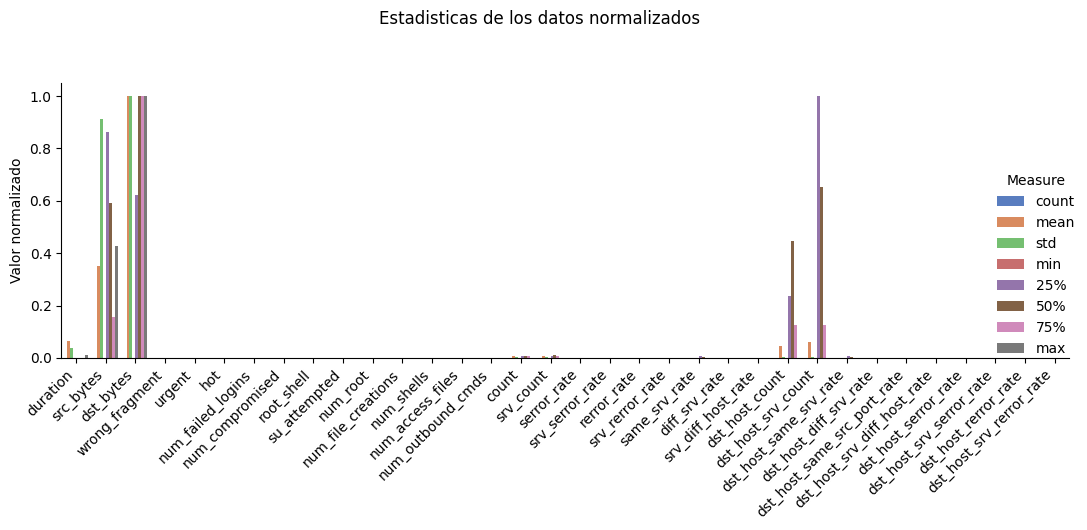

In [80]:
#Análisis de los datos:
summary_stats = df.describe()

# Normalizar los datos utilizando Min-Max scaling
scaler = MinMaxScaler()
summary_stats_normalized = scaler.fit_transform(summary_stats.T).T

# Convertir los datos normalizados en un DataFrame para usar con sns.catplot()
summary_stats_normalized_df = pd.DataFrame(summary_stats_normalized, columns=summary_stats.columns, index=summary_stats.index)

# Transponer el DataFrame para que las características estén en el eje x
summary_stats_normalized_df = summary_stats_normalized_df.T.reset_index()

# Apilar las medidas estadísticas en una sola columna para hacerlas compatibles con sns.catplot()
summary_stats_normalized_stacked = summary_stats_normalized_df.melt(id_vars=['index'], var_name='Measure', value_name='Value')

# Crear un gráfico de barras agrupado por la medida estadística
g = sns.catplot(data=summary_stats_normalized_stacked, kind='bar', x='index', y='Value', hue='Measure', palette='muted', aspect=2)
g.set_xticklabels(rotation=45, ha='right')
g.set_axis_labels('', 'Valor normalizado')
g.fig.suptitle('Estadisticas de los datos normalizados', y=1.05)
plt.tight_layout()
plt.show()

In [81]:
#Defino el preproceso

# Definir columnas numéricas y categóricas
numeric_features = ["duration", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent", "hot", 
                    "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted",
                    "num_root", "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
                    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
                    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
                    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
                    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
                    "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate"]
categorical_features = ["protocol_type", "service", "flag"]

# Definir el preprocesamiento para características numéricas
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Manejo de valores faltantes
    ('scaler', StandardScaler())  # Escalado de características
])

# Definir el preprocesamiento para características categóricas
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Manejo de valores faltantes
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # Codificación one-hot
])

# Definir el preprocesamiento completo utilizando ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Definir el pipeline completo incluyendo el preprocesamiento
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])


# Detección de anomalías

Si bien *scikit-learn* proporciona algunas herramientas para la detección de anomalías, esta actividad se centra en la utilización de algoritmos no supervisados generalmente pensados para otras tareas como: reducción de la dimensionalidad, y/o *clustering*. Específicamente se trabajará con: PCA, *K-Means*, y *Gaussian Mixture Model* (GMM).

## PCA


El análisis de componentes principales (**PCA**) es una técnica de reducción de la dimensionalidad que permite representar los datos en un espacio de menor dimensión manteniendo la mayor cantidad posible de información. 

En la *Parte 1* se deberá seleccionar la cantidad de componentes principales que se utilizarán en el modelo. También, se sugiere utilizar esta técnica como una herramienta de visualización de datos.

Luego, en la *Parte 2* se implementa un detector de anomalías utilizando esta técnica.

### Parte 1


#### Ejercicios:

 - Aplicar PCA sobre los datos de entrenamiento y graficar como varía el porcentaje de la varianza total en función de la cantidad de componentes principales (CPs). Se sugiere ver la sección *Choosing the Right Number of Dimensions* del capítulo 8 del libro. 
 - Determinar la cantidad de CPs de manera de mantener el *99%* de la varianza de los datos.
 - Utilizando PCA visualice los datos en dos o tres dimensiones. ¿Logra identificar clusters? *Para esta parte puede resultar útil comparar según la proyeccion de datos Normales contra las proyecciones de los datos Anómalos según el tipo de ataque.*

### Def de PCA:

Principal Component Analysis (PCA) is by far the most popular dimensionality reduc‐ tion algorithm. First it identifies the hyperplane that lies closest to the data, and then it projects the data onto it.

### Conclusión:
Esto nos muestra que tomando el 99% que equivale a 32CP podemos reducir las dimensiones en un 45% y no perder varianza.

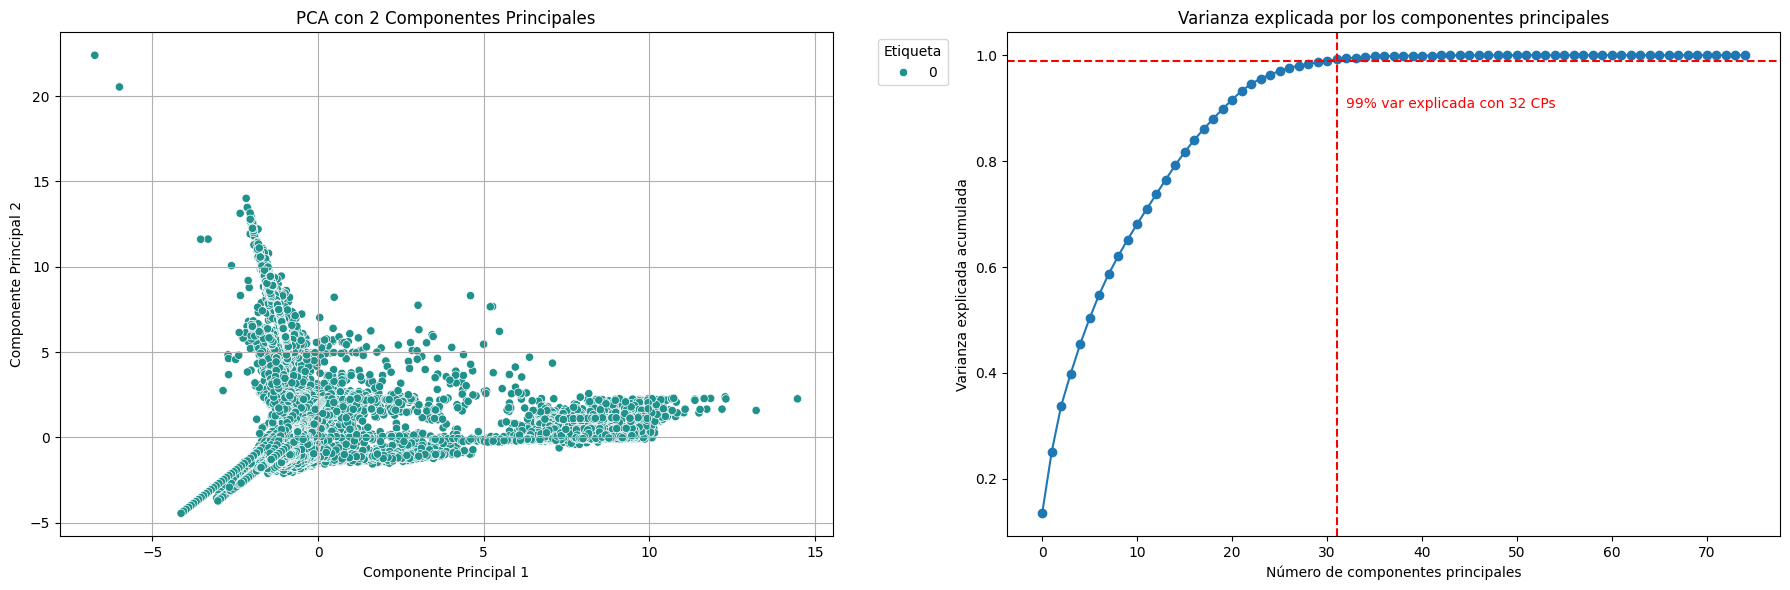

In [156]:
# Aplicamos el preprocesamiento y luego PCA
X_train_processed = pipeline.fit_transform(X_train)
pca = PCA()
X_train_pca = pca.fit_transform(X_train_processed)

# Calculamos la varianza explicada y la varianza explicada acumulada
explained_variance_ratio = pca.explained_variance_ratio_
explained_variance_cumulative = np.cumsum(explained_variance_ratio)

# Encuentra el número de componentes para el 99% de varianza explicada
num_components_99 = np.where(explained_variance_cumulative >= 0.99)[0][0] + 1

# PCA para dos dimensiones
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_processed)
df_pca_2d = pd.DataFrame(X_train_2d, columns=['PC1', 'PC2'])
df_pca_2d['label'] = y_train


fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Grafico de PCA en 2D
sns.scatterplot(data=df_pca_2d, x='PC1', y='PC2', hue='label', palette='viridis', style='label', markers=True, ax=axes[0])
axes[0].set_title('PCA con 2 Componentes Principales')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')
axes[0].legend(title='Etiqueta', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True)

# Varianza explicada acumulada
axes[1].plot(explained_variance_cumulative, marker='o')
axes[1].axhline(y=0.99, color='r', linestyle='--')
axes[1].axvline(x=num_components_99 - 1, color='r', linestyle='--')
axes[1].text(num_components_99, 0.9, f'99% var explicada con {num_components_99} CPs', color="red")
axes[1].set_xlabel('Número de componentes principales')
axes[1].set_ylabel('Varianza explicada acumulada')
axes[1].set_title('Varianza explicada por los componentes principales')

plt.tight_layout()
plt.show()


### Parte 2

La forma más directa de hacer detección de anomalías utilizando PCA, es mediante el error de reconstrucción. Para esto primero se calculan los componentes principales a partir de los datos de entrenamiento. Luego para cada dato a analizar se lo proyecta sobre estos componentes, y se calcula su reconstrucción. Debido a que los CPs fueron calculado sólo con datos normales, se espera que la reconstrucción de datos anómalos tengan mayores errores. Es por esto que a partir del error de reconstrucción se puede determinar si un dato es anómalo o no.

#### Objetivos:

*   Implementar un detector tal como se describe arriba, utilizando RMSE para calcular el error. El mismo se debe definir como una clase de manera que sea compatible con los *pipelines* de *scikit-learn*. En la siguiente celda se muestra un *template* para crear la clase ([aquí](https://scikit-learn.org/stable/developers/develop.html) se pueden ver otros ejemplos).

*   Crear un *pipeline* que incluya el preprocesamiento y el detector implementado.
*   Entrenar el modelo de manera que mantenga el *99%* de la varianza. 
*   Proponga un punto de operación teniendo en cuenta que se quiere evitar un exceso de falsas alarmas. Para ello se recomienda graficar el compromiso entre *precision* y *recall* para distintos valores de *threshold* que definen el punto de operación. Ver la sección *Precision/Recall Trade-off* del capítulo 3 del libro.
*   Graficar los *scores* de los datos utilizados en el punto anterior, diferenciando con colores los datos normales de los anómalos.
*    Evaluar el desempeño en el conjunto de Validación y Test. Puede resultar útil tener la tasa de aciertos por categoría de anomalía.

In [157]:
# Defino la clase AD_PCA que hereda de BaseEstimator y OutlierMixin lo que permite que sea compatible con el pipeline.  

# Defino la clase AD_PCA que hereda de BaseEstimator y OutlierMixin lo que permite que sea compatible con el pipeline.  
# Esta clase debe tener los métodos fit y score. 

# Importo las librerías necesarias
from sklearn.base import BaseEstimator, OutlierMixin
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.metrics import mean_squared_error

class AD_PCA(BaseEstimator, OutlierMixin):
    def __init__(self, n_comp=None):
        '''
        
        Constructor de la clase.

        Parametros:
            n_comp: cantidad de componentes principales a utilizar
            
        '''
        self.n_comp = n_comp
    
    def fit(self, X, y=None):
        '''
        Se entrena el modelo.

        Parametros:
            X: matriz de datos
            y: etiquetas (no son necesarias)
        
        Retorna:
            self: el objeto     
        '''
        self.X = X
        self.y = y 
        
        self.pca = PCA(n_components=self.n_comp)
        self.pca.fit(X)    
        return self
    
    def score(self, X, y=None):  
        '''     
        Se calcula el error de reconstrucción de cada muestra. 
        

        Parametros:
            X: matriz de datos
            y: etiquetas (no son necesarias)

        Retorna:
            score: el RMSE de cada muestra reconstruida. 
        ''' 
        # Se verifica que los datos sean válidos
        X = check_array(X)
        
        # Se verifica que el modelo haya sido entrenado
        check_is_fitted(self, ['X', 'y'])

        # Proyectar los datos en el espacio de los componentes principales
        X_pca = self.pca.transform(X)
        
        # Reconstruir los datos
        X_reconstructed = self.pca.inverse_transform(X_pca)
        
        score = np.sqrt(np.mean((X - X_reconstructed) ** 2, axis=1))

        return score

In [158]:
# Creamos el pipeline
pipeline_PCA = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('detector', AD_PCA(n_comp=32)) 
])

In [159]:
#Ajustamos a los datos
pipeline_PCA.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   'num_file_creations',
                                                   'num_shells',
                                                   'num_ac...
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['protocol_type', 'service',
                                                   'flag'])])),
                ('detector', AD_PCA(n_comp=32))])

In [162]:
def plot_precision_recall_vs_threshold2(precisions, recalls, thresholds, chosen_threshold):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.legend(loc="lower right") # Agregar leyenda
    plt.xlabel("Threshold") # Etiqueta del eje x
    plt.ylabel("Precision/Recall") # Etiqueta del eje y
    plt.grid(True) # Agregar cuadrícula

    # Obtener un índice booleano para el umbral seleccionado
    threshold_idx = np.where(np.isclose(thresholds, chosen_threshold))[0][0]
    # Resaltar el umbral en el gráfico con línea punteada vertical
    plt.axvline(x=chosen_threshold, color='red', linestyle='--', linewidth=0.5)
    # Plot del punto rojo con menor tamaño
    plt.plot(chosen_threshold, precisions[threshold_idx], 'ro', markersize=3) # Punto rojo en el umbral seleccionado con menor tamaño
    plt.plot(chosen_threshold, recalls[threshold_idx], 'ro', markersize=3) # Punto rojo en el umbral seleccionado con menor tamaño
    plt.annotate('Umbral elegido', # Etiqueta del punto
                 xy=(chosen_threshold, precisions[threshold_idx]), # Coordenadas del punto
                 xytext=(chosen_threshold + 0.1, precisions[threshold_idx] - 0.2), # Coordenadas del texto
                 arrowprops=dict(facecolor='black', arrowstyle='->')) # Propiedades de la flecha

In [163]:
y_val_score_pca = pipeline_PCA.score(X_val)

precisions, recalls, thresholds = precision_recall_curve(y_val,y_val_score_pca)

target_precision = 0.80
valid_indices = np.where(precisions >= target_precision)[0]  # Índices donde la precisión es al menos 80%
highest_recall_idx = valid_indices[np.argmax(recalls[valid_indices])]  # Índice con el mayor recall entre los índices válidos
chosen_threshold = thresholds[highest_recall_idx]

print("Threshold elegido:", chosen_threshold)



Threshold elegido: 0.050766347282344026


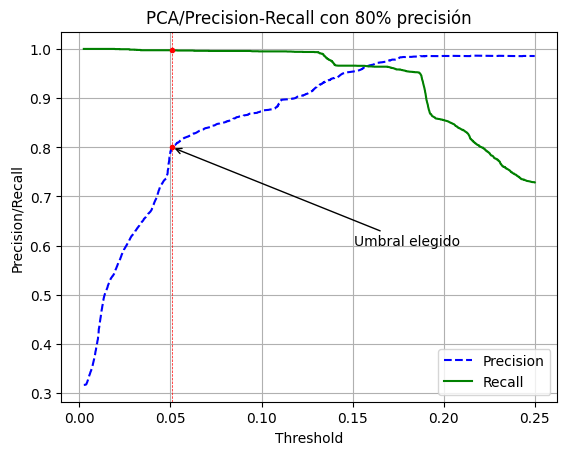

In [164]:
threshold_limit = 0.25

# Filtrar los valores para que solo incluyan thresholds hasta 0.3
max_index = np.where(thresholds <= threshold_limit)[0][-1]
filtered_precisions = precisions[:max_index+2]  # Incluye un elemento más para compensar el recorte
filtered_recalls = recalls[:max_index+2]
filtered_thresholds = thresholds[:max_index+1]

plot_precision_recall_vs_threshold2(filtered_precisions, filtered_recalls, filtered_thresholds, chosen_threshold)
plt.title('PCA/Precision-Recall con 80% precisión')

plt.show()

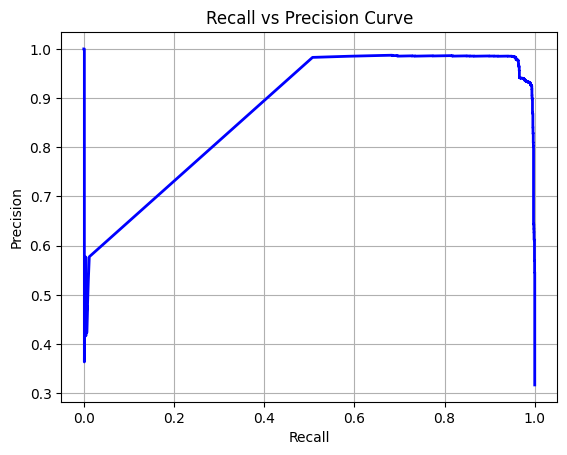

In [165]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

def plot_recall_vs_precision(recalls, precisions):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Recall vs Precision Curve")
    plt.grid(True)

y_val_score_pca = pipeline_PCA.score(X_val)

precisions, recalls, _ = precision_recall_curve(y_val, y_val_score_pca)

plot_recall_vs_precision(recalls, precisions)
plt.show()


In [166]:
# Suponiendo que ya has calculado 'chosen_threshold' como antes
# Calcular los errores de reconstrucción para cada muestra en los conjuntos de validación y test
val_errors = pipeline_PCA.score(X_val)
test_errors = pipeline_PCA.score(X_test)

# Usar el umbral para clasificar cada muestra en normal (0) o anomalía (1)
val_predictions = (val_errors > chosen_threshold).astype(int)
test_predictions = (test_errors > chosen_threshold).astype(int)

# Calcular y mostrar la proporción de anomalías detectadas
val_anomaly_rate = np.mean(val_predictions)
test_anomaly_rate = np.mean(test_predictions)

print("Proporción de anomalías detectadas en el conjunto de Validación: {:.2f}%".format(val_anomaly_rate * 100))
print("Proporción de anomalías detectadas en el conjunto de Test: {:.2f}%".format(test_anomaly_rate * 100))


Proporción de anomalías detectadas en el conjunto de Validación: 39.50%
Proporción de anomalías detectadas en el conjunto de Test: 78.99%


Se otorga una función que, dadas las predicciones, devuelve la tasa de acierto por tipo de anomalía.

In [109]:
def aciertos_por_clase(y, y_pred ,y_g_truth):
    
    '''
    
    Parametros:
        y = Etiquetas del conjunto en Formato 0 o 1
        y_pred = Predicciones en el conjunto en Formato True o False
        y_g_truth = Etiquetas del conjunto en formato string indicando el tipo de anomalía. 
    
    Retorna:
        Devuelve un Dataframe con la tasa de aciertos por Clase.
        
    '''
    
    aciertos = ( (y_pred.flatten()*1) == y.flatten())
    type_of_anomaly = list(np.unique(y_g_truth))
    acc_class = []
    
    for i_an in range(len(type_of_anomaly)):
        mask_anomaly  = y_g_truth == type_of_anomaly[i_an] 
        total_tipo = np.count_nonzero(mask_anomaly)
        acc_class.append(np.count_nonzero(aciertos & mask_anomaly)/total_tipo)
        
    return pd.DataFrame([acc_class], columns=type_of_anomaly)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


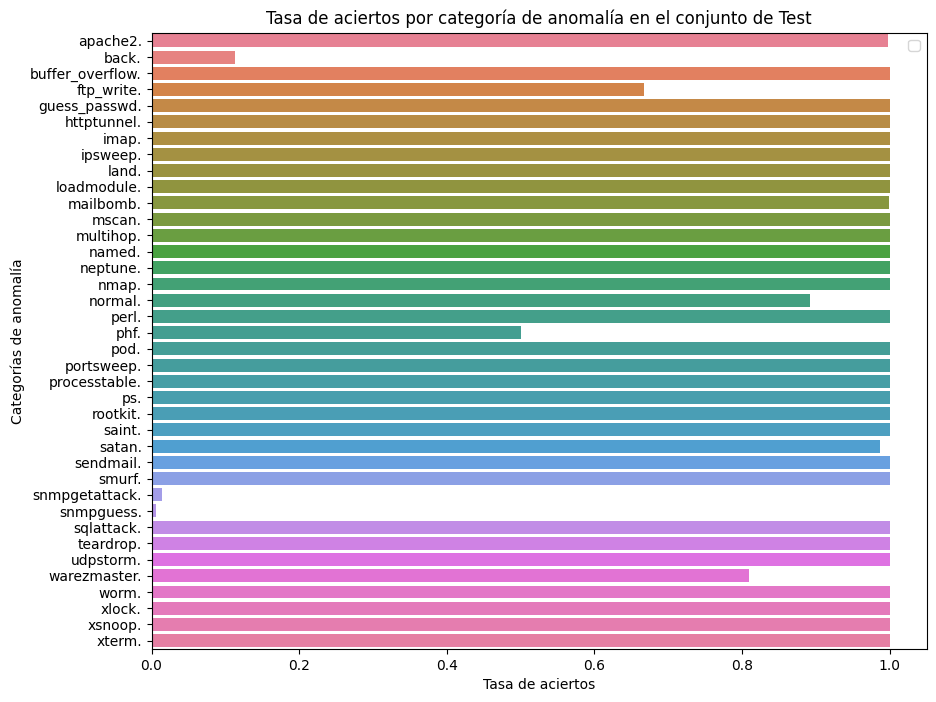

In [169]:
# Umbral para determinar si una muestra es anómala
umbral = chosen_threshold  # Este valor es un ejemplo

# Calcular y_pred basándose en el umbral, convirtiendo las Series a NumPy arrays con .values
y_val_pred = val_errors > umbral
y_test_pred = test_errors > umbral

# Convertir de pandas Series a numpy arrays si no se ha hecho aún
y_val_np = (y_val > 0).astype(int).values
y_test_np = (y_test > 0).astype(int).values
y_val__np = y_val_.values
y_test__np = y_test_.values

# Usar la función aciertos_por_clase para calcular la tasa de aciertos por clase
val_acc_by_class = aciertos_por_clase(y_val_np, y_val_pred, y_val__np)
test_acc_by_class = aciertos_por_clase(y_test_np, y_test_pred, y_test__np)


def plot_accuracy_by_category(df, title, figsize=(10, 8)):
    plt.figure(figsize=figsize)
    ax = sns.barplot(data=df.T, x=0, y=df.T.index, hue=df.T.index, dodge=False)
    ax.set_title(title)
    ax.set_xlabel("Tasa de aciertos")
    ax.set_ylabel("Categorías de anomalía")
    ax.legend(title=None)  # Para eliminar el título de la leyenda
    plt.show()

# Asumiendo que val_acc_by_class y test_acc_by_class son los DataFrames que contienen los scores
# plot_accuracy_by_category(val_acc_by_class, "Tasa de aciertos por categoría de anomalía en el conjunto de Validación")
plot_accuracy_by_category(test_acc_by_class, "Tasa de aciertos por categoría de anomalía en el conjunto de Test")

## K-Means

A continuación se implementará un detector de anomalías utilizando el modelo K-Means.

En la *Parte 1*, se llevará a cabo la determinación del número óptimo de clusters necesarios para el problema. En la *Parte 2* se implementará un detector de anomalías.

Para facilitar la construcción del detector, se sugiere implementar un único pipeline que incluya tanto el preprocesamiento como el modelo. 

### Parte 1


#### Ejercicio:

 - Implementar una forma de hallar la cantidad de clusters de K-Means óptima . Se sugiere ver la sección *Finding the optimal number of clusters* del Capítulo 9. 
 
**Comentario**: Emplear alguno de los métodos sugeridos toma un tiempo no menor, se sugiere: (i) economizar las búsquedas, (ii) utilizar semillas, (iii) en cuánto tenga los resultados guardelos en formato *.npy*, *.txt* u otro que considere, para que luego pueda cargar en caso que desee rehacer una gráfica. Seguir esta práctica evita que tenga que volver a correr el experimento.  

In [112]:
# Definir el rango de número de clusters a probar
min_clusters = 2
max_clusters = 10
range_clusters = range(min_clusters, max_clusters + 1)

# Utilizar semilla aleatoria para reproducibilidad
np.random.seed(42)

# Calcular la puntuación de silueta para cada número de clusters
silhouette_scores = []
for n_clusters in range_clusters:
    kmeans = KMeans(n_clusters=n_clusters)
    labels = kmeans.fit_predict(X_train_processed)
    silhouette_scores.append(silhouette_score(X_train_processed, labels))

# Encontrar el número óptimo de clusters con la puntuación de silueta más alta
optimal_num_clusters = range_clusters[np.argmax(silhouette_scores)]
optimal_silhouette_score = max(silhouette_scores)

print("Número óptimo de clusters:", optimal_num_clusters)
print("Puntuación de silueta más alta:", optimal_silhouette_score)

# Guardar los resultados en archivos .npy
np.save('silhouette_scores.npy', silhouette_scores)
np.save('optimal_num_clusters.npy', optimal_num_clusters)
np.save('optimal_silhouette_score.npy', optimal_silhouette_score)


KeyboardInterrupt: 

### Parte 2


Una vez seleccionada la cantidad óptima de clusters, se procederá a construir el detector de anomalías utilizando el modelo K-Means. Hay diferentes formas de usar este algoritmo, se sugiere  entrenar el modelo primero y luego calcular la distancia al cluster más cercano. Si esta distancia supera un umbral a definir entonces la muestra se clasificará como anómala.

#### Ejercicios:

- Implementar un detector de anomalías utilizando *K-Means*. Para ello cree una clase y un *pipeline* que lo implemente de forma análoga a lo realizado con el método de PCA.
-   Proponga un punto de operación teniendo en cuenta el compromiso entre *precision* y *recall* para distintos valores de *threshold* que definen el punto de operación. 
-   Graficar los *scores* de los datos utilizados en el punto anterior, diferenciando con colores los datos normales de los anómalos. 
- Evaluar el desempeño en el conjunto de Validación y Test.

In [146]:
# Define la clase AD_Kmeans que hereda de BaseEstimator y OutlierMixin para que sea compatible con el pipeline.
class AD_Kmeans(BaseEstimator, OutlierMixin):
    def __init__(self, n_clusters=None):
        '''
        Constructor de la clase.

        Parámetros:
            n_clusters: cantidad de clusters a utilizar
        '''
        self.n_clusters = n_clusters
    
    def fit(self, X, y=None):
        '''
        Se entrena el modelo.

        Parámetros:
            X: matriz de datos
            y: etiquetas (no son necesarias)

        Retorna:
            self: el objeto
        '''
        # Se verifica que los datos sean válidos
        X = check_array(X)
        
        # Ajusta el modelo KMeans a los datos
        self.kmeans_model = KMeans(n_clusters=self.n_clusters)
        self.kmeans_model.fit(X)
        
        return self
    
    def score(self, X, y=None):
        '''
        Se calcula la distancia mínima de cada muestra a los centroides de los clústeres.

        Parámetros:
            X: matriz de datos
            y: etiquetas (no son necesarias)

        Retorna:
            d_min: la distancia mínima de cada muestra a los centroides de los clústeres.
        '''
        # Se verifica que los datos sean válidos
        X = check_array(X)
        
        # Se verifica que el modelo haya sido entrenado
        check_is_fitted(self, ['kmeans_model'])
        
        # Calcula la distancia mínima de cada muestra a los centroides
        distances = self.kmeans_model.transform(X)
        d_min = np.min(distances, axis=1)
    
        return d_min


In [147]:
# Pipeline
pipeline_Kmeans = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('detector', AD_Kmeans(n_clusters=6))
])

In [148]:
# Ajusta 
pipeline_Kmeans.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   'num_file_creations',
                                                   'num_shells',
                                                   'num_ac...
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['protocol_type', 'service',
                                                   'flag'])])),
                ('detector', AD_Kmeans(n_clusters=6))])

Threshold elegido: 3.696585936032848


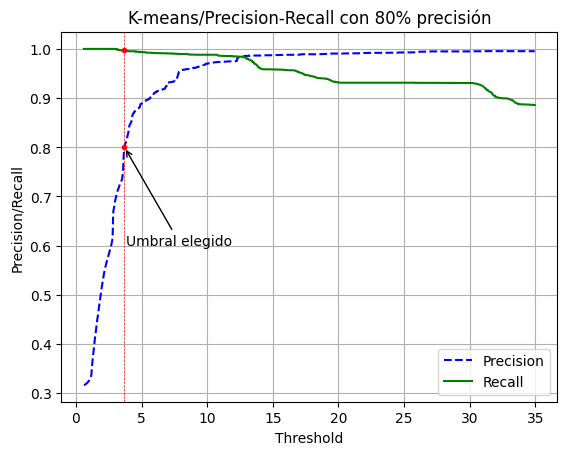

In [149]:
y_val_score_kmeans = pipeline_Kmeans.score(X_val)

precisions, recalls, thresholds = precision_recall_curve(y_val,y_val_score_kmeans)

# Encontrar el índice donde la precisión es más cercana al 80% y maximizar el recall
target_precision = 0.80
valid_indices = np.where(precisions >= target_precision)[0]  # Índices donde la precisión es al menos 80%
highest_recall_idx = valid_indices[np.argmax(recalls[valid_indices])]  # Índice con el mayor recall entre los índices válidos
chosen_threshold = thresholds[highest_recall_idx]

print("Threshold elegido:", chosen_threshold)

threshold_limit = 35

# Filtrar los valores para que solo incluyan thresholds hasta 0.3
max_index = np.where(thresholds <= threshold_limit)[0][-1]
filtered_precisions = precisions[:max_index+2]  # Incluye un elemento más para compensar el recorte
filtered_recalls = recalls[:max_index+2]
filtered_thresholds = thresholds[:max_index+1]

plot_precision_recall_vs_threshold2(filtered_precisions, filtered_recalls, filtered_thresholds, chosen_threshold)
plt.title('K-means/Precision-Recall con 80% precisión')
plt.show()

In [117]:
val_errors = pipeline_Kmeans.score(X_val)
test_errors = pipeline_Kmeans.score(X_test)

# Usar el umbral para clasificar cada muestra en normal (0) o anomalía (1)
val_predictions = (val_errors > chosen_threshold).astype(int)
test_predictions = (test_errors > chosen_threshold).astype(int)

# Calcular y mostrar la proporción de anomalías detectadas
val_anomaly_rate = np.mean(val_predictions)
test_anomaly_rate = np.mean(test_predictions)

print("Proporción de anomalías detectadas en el conjunto de Validación: {:.2f}%".format(val_anomaly_rate * 100))
print("Proporción de anomalías detectadas en el conjunto de Test: {:.2f}%".format(test_anomaly_rate * 100))


Proporción de anomalías detectadas en el conjunto de Validación: 79.22%
Proporción de anomalías detectadas en el conjunto de Test: 94.05%


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


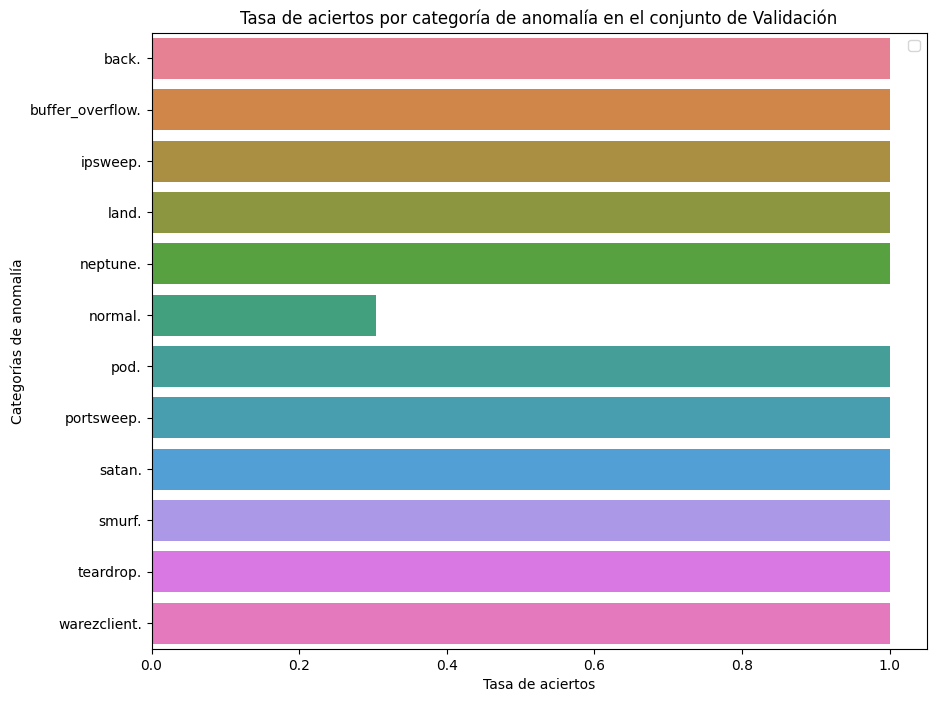

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


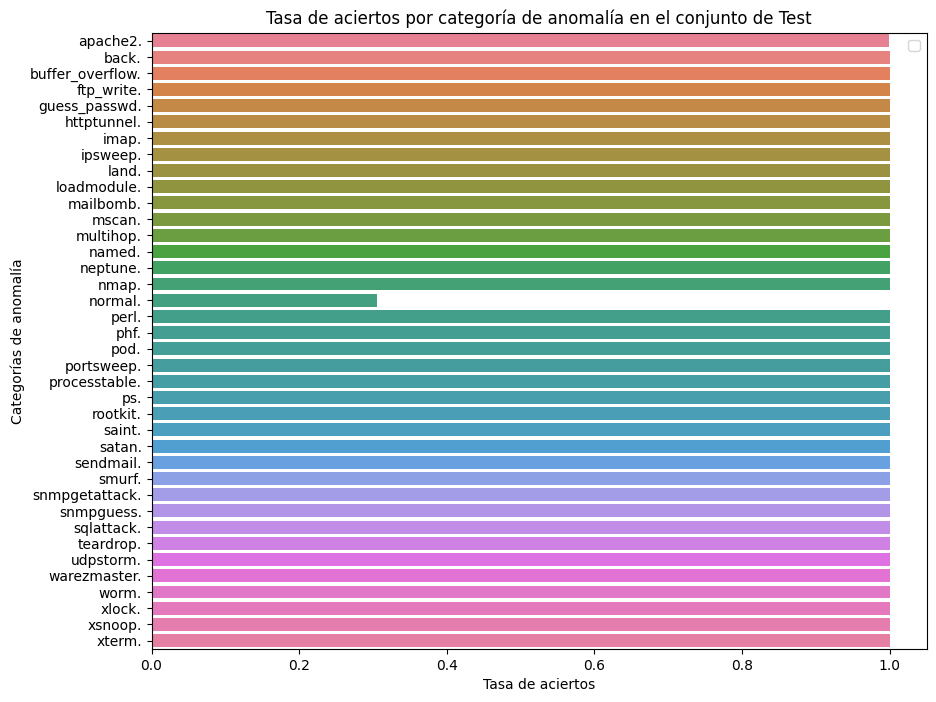

In [119]:
# Umbral para determinar si una muestra es anómala
umbral = chosen_threshold  # Este valor es un ejemplo

# Calcular y_pred basándose en el umbral, convirtiendo las Series a NumPy arrays con .values
y_val_pred = val_errors > umbral
y_test_pred = test_errors > umbral

# Convertir de pandas Series a numpy arrays si no se ha hecho aún
y_val_np = (y_val > 0).astype(int).values
y_test_np = (y_test > 0).astype(int).values
y_val__np = y_val_.values
y_test__np = y_test_.values

# Usar la función aciertos_por_clase para calcular la tasa de aciertos por clase
val_acc_by_class = aciertos_por_clase(y_val_np, y_val_pred, y_val__np)
test_acc_by_class = aciertos_por_clase(y_test_np, y_test_pred, y_test__np)


def plot_accuracy_by_category(df, title, figsize=(10, 8)):
    plt.figure(figsize=figsize)
    ax = sns.barplot(data=df.T, x=0, y=df.T.index, hue=df.T.index, dodge=False)
    ax.set_title(title)
    ax.set_xlabel("Tasa de aciertos")
    ax.set_ylabel("Categorías de anomalía")
    ax.legend(title=None)  # Para eliminar el título de la leyenda
    plt.show()

# Asumiendo que val_acc_by_class y test_acc_by_class son los DataFrames que contienen los scores
plot_accuracy_by_category(val_acc_by_class, "Tasa de aciertos por categoría de anomalía en el conjunto de Validación")
plot_accuracy_by_category(test_acc_by_class, "Tasa de aciertos por categoría de anomalía en el conjunto de Test")

## Gaussian Mixtures Models

Por último, se implementará un detector de anomalías utilizando el modelo mezcla de gaussianas (GMM).

En la *Parte 1*, se llevará a cabo la determinación del número óptimo de clusters necesarios para el problema. Una vez seleccionado el número adecuado de clusters, se procederá a la construcción del clasificador en la *Parte 2*.

Nuevamente, para facilitar la construcción del detector, se sugiere implementar un único pipeline que incluya tanto el preprocesamiento como el modelo.

### Parte 1


Siga el ejemplo de la sección *Anomaly Detection Using Gaussian Mixture* en el Capítulo 9 del libro, y determine la cantidad óptima de mezclas a utilizar por el modelo.


#### Ejercicio:

 - Proponer una forma de hallar la cantidad óptima de mezclas a utilizar.
 
 **Comentario**: Emplear alguno de los métodos sugeridos toma un tiempo no menor, se sugiere: (i) economizar las búsquedas, (ii) utilizar semillas, (iii) en cuánto tenga los resultados guardelos en formato *.npy*, *.txt* u otro que considere, para que luego pueda cargar en caso que desee rehacer una gráfica. Seguir esta práctica evita que tenga que volver a correr el experimento.  

In [170]:
# Definir el rango de número de componentes a probar
min_components = 2
max_components = 10
range_components = range(min_components, max_components + 1)

# Utilizar semilla aleatoria para reproducibilidad
np.random.seed(42)

# Calcular el BIC y AIC para cada número de componentes
bic_scores = []
aic_scores = []
for n_components in range_components:
    gm = GaussianMixture(n_components=n_components)
    gm.fit(X_train_processed)
    bic = gm.bic(X_train_processed)
    aic = gm.aic(X_train_processed)
    bic_scores.append(bic)
    aic_scores.append(aic)

# Encontrar el número óptimo de componentes con el BIC más bajo
optimal_num_components_bic = range_components[np.argmin(bic_scores)]
min_bic = min(bic_scores)

# Encontrar el número óptimo de componentes con el AIC más bajo
optimal_num_components_aic = range_components[np.argmin(aic_scores)]
min_aic = min(aic_scores)

print("Número óptimo de componentes según BIC:", optimal_num_components_bic)
print("Valor mínimo de BIC:", min_bic)

print("Número óptimo de componentes según AIC:", optimal_num_components_aic)
print("Valor mínimo de AIC:", min_aic)

# Guardar los resultados en archivos .npy
np.save('bic_scores.npy', bic_scores)
np.save('aic_scores.npy', aic_scores)
np.save('optimal_num_components_bic.npy', optimal_num_components_bic)
np.save('optimal_num_components_aic.npy', optimal_num_components_aic)
np.save('min_bic.npy', min_bic)
np.save('min_aic.npy', min_aic)

Número óptimo de componentes según BIC: 10
Valor mínimo de BIC: -59141240.94489005
Número óptimo de componentes según AIC: 10
Valor mínimo de AIC: -59416496.88774198



### Parte 2

Siguiendo también el el ejemplo de la sección *Anomaly Detection Using Gaussian Mixture* en el Capítulo 9 del libro, construya y entrene un clasificador de anomalías utilizando la cantidad de mezclas determinadas en la parte anterior. 

Una vez entrenado el modelo, se calcula la log-verosimilitud de cada muestra y se umbraliza para detectar anomalías. Si el valor de la log-verosimilitud es menor que un umbral determinado, se considera que la muestra es anómala.

El valor del umbral se fija a partir de determinar la proporción de muestras que se clasifican como anómalas. Por ejemplo, si se sabe de antemano que los ataques constituyen un porcentaje $\alpha$ de las muestras, se puede calcular el valor que define el percentil correspondiente a este $\alpha$% en la escala de log-verosimilitud para clasificar las muestras como anómalas.


#### Ejercicios:

*   Implementar un detector que calcule el valor de los *scores*, la log-verosimilitud en este caso. En la siguiente celda se proporciona un *template* para la implementación del detector.
*   Fijar un umbral en validación utilizando algún percentil similar a lo realizado en el Capítulo 9 del libro. Se obtendrán distintos puntos de funcionamiento en función del percentil elegido. Discutir sobre los resultados obtenidos.
*   Evaluar el desempeño en el conjunto de Validación y Test. 

In [150]:
#Defino el estimador

# Importo las bibliotecas necesarias
from sklearn.mixture import GaussianMixture
from sklearn.base import BaseEstimator, OutlierMixin
from sklearn.utils.validation import check_array, check_is_fitted

# Defino la clase AD_GMM que hereda de BaseEstimator y OutlierMixin lo que permite que sea compatible con el pipeline.
# Esta clase debe tener los métodos fit y score.
class AD_GMM(BaseEstimator, OutlierMixin):
    def __init__(self, n_comp=None):
        '''
        
            Constructor de la clase.

            Parametros:
                n_comp: cantidad de componentes principales a utilizar
                
        '''

        self.n_comp = n_comp
    
    def fit(self, X, y=None):
        '''
        
            Se entrena el modelo.

            Parametros:
                X: matriz de datos
                y: etiquetas (no son necesarias)

            Retorna:
                self: el objeto

        '''

        self.classes_ = [1, 0]
        self.X = X
        self.y = y 
        
        # Inicializar el modelo de mezclas gaussianas
        self.gmm = GaussianMixture(n_components=self.n_comp)
        
        # Entrenar el modelo de mezclas gaussianas
        self.gmm.fit(X)
        
        return self
    
    def score(self, X, y=None):
        '''
        
            Se calcula la log-verosimilitud de cada muestra.
            
            Parametros:
                X: matriz de datos
                y: etiquetas (no son necesarias)
            
            Retorna:
                score: el score de cada muestra.
                
        '''
        # Se verifica que los datos sean válidos
        X = check_array(X)

        # Se verifica que el modelo haya sido entrenado
        check_is_fitted(self, ['gmm'])

        # Calcula la probabilidad de cada muestra bajo la distribución GMM
        log_likelihood = self.gmm.score_samples(X)

        # Calcula la distancia mínima como el negativo de la log-verosimilitud
        score = -log_likelihood
        
        return score


In [151]:
# Creamos el pipeline
pipeline_GMM = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('detector', AD_GMM(n_comp=10)) 
])

In [152]:
# Ajusto
pipeline_GMM.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   'num_file_creations',
                                                   'num_shells',
                                                   'num_ac...
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['protocol_type', 'service',
                                                   'flag'])])),
                ('detector', AD_GMM(n_comp=10))])

Threshold elegido: -200.30410037759665


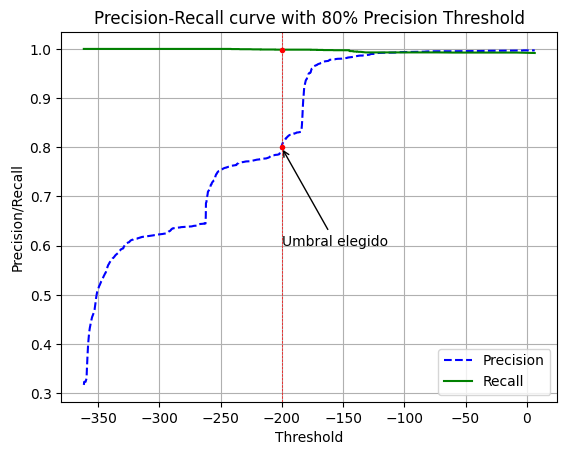

In [153]:
y_val_score_gmm = pipeline_GMM.score(X_val)

precisions, recalls, thresholds = precision_recall_curve(y_val,y_val_score_gmm)

# Encontrar el índice donde la precisión es más cercana al 80% y maximizar el recall
target_precision = 0.80
valid_indices = np.where(precisions >= target_precision)[0]  # Índices donde la precisión es al menos 80%
highest_recall_idx = valid_indices[np.argmax(recalls[valid_indices])]  # Índice con el mayor recall entre los índices válidos
chosen_threshold = thresholds[highest_recall_idx]

print("Threshold elegido:", chosen_threshold)

threshold_limit = 35

# Filtrar los valores para que solo incluyan thresholds hasta 0.3
max_index = np.where(thresholds <= threshold_limit)[0][-1]
filtered_precisions = precisions[:max_index+2]  # Incluye un elemento más para compensar el recorte
filtered_recalls = recalls[:max_index+2]
filtered_thresholds = thresholds[:max_index+1]

plot_precision_recall_vs_threshold2(filtered_precisions, filtered_recalls, filtered_thresholds, chosen_threshold)
plt.title('Precision-Recall curve with 80% Precision Threshold')
plt.show()

In [154]:
# Calcular los errores de distancia mínima para cada muestra en los conjuntos de validación y test
val_errors = pipeline_GMM.score(X_val)
test_errors = pipeline_GMM.score(X_test)

val_predictions = (val_errors > chosen_threshold).astype(int)
test_predictions = (test_errors > chosen_threshold).astype(int)

# Calcular y mostrar la proporción de anomalías detectadas
val_anomaly_rate = np.mean(val_predictions)
test_anomaly_rate = np.mean(test_predictions)

print("Proporción de anomalías detectadas en el conjunto de Validación: {:.2f}%".format(val_anomaly_rate * 100))
print("Proporción de anomalías detectadas en el conjunto de Test: {:.2f}%".format(test_anomaly_rate * 100))


Proporción de anomalías detectadas en el conjunto de Validación: 39.55%
Proporción de anomalías detectadas en el conjunto de Test: 76.79%


# Opcional

*   Aplicar a los datos del problema alguno de los detectores de *sikit-learn* como: One-Class SVM, Isolation Forest
*   Realizar ingeniería de características.
*   Combinar PCA con K-Means y/o GMM
